# Page-Level Analysis

Visualizations for the page-level dataset produced by `build_datasets.py`. Focuses on per-page detection distributions, confidence breakdowns, spatial zones, classification types, and coverage by redaction level.

In [ ]:
# Cell 1: Install Dependencies
!pip install matplotlib seaborn

In [1]:
# Cell 2: Imports & Configuration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PALETTE = "Set2"
DEFAULT_FIGSIZE = (10, 6)
WIDE_FIGSIZE = (14, 5)
HIST_KWARGS = dict(bins=30, edgecolor="black", alpha=0.7)

In [2]:
# Cell 3: Load Data
# >>> UPDATE THIS PATH to point to your page-level CSV <<<
DATA_PATH = "../data/page_level.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print()
df.dtypes

Shape: (446789, 31)



relative_path          object
folder_name            object
page_filename          object
arbitration_id         object
year                    int64
doc_name               object
match_method           object
status                 object
error                 float64
total_detections        int64
high_confidence         int64
medium_confidence       int64
low_confidence          int64
coverage_fraction     float64
coverage_percent      float64
redaction_area_px       int64
content_area_px         int64
inline_count            int64
partial_line_count      int64
full_line_count         int64
block_count             int64
header_count            int64
body_count              int64
footer_count            int64
vertical_spread       float64
redaction_level        object
heaviness_score         int64
image_width             int64
image_height            int64
estimated_dpi         float64
skew_angle            float64
dtype: object

## Distributions

Histograms are filtered to rows where the plotted value > 0 to avoid a large spike at zero.

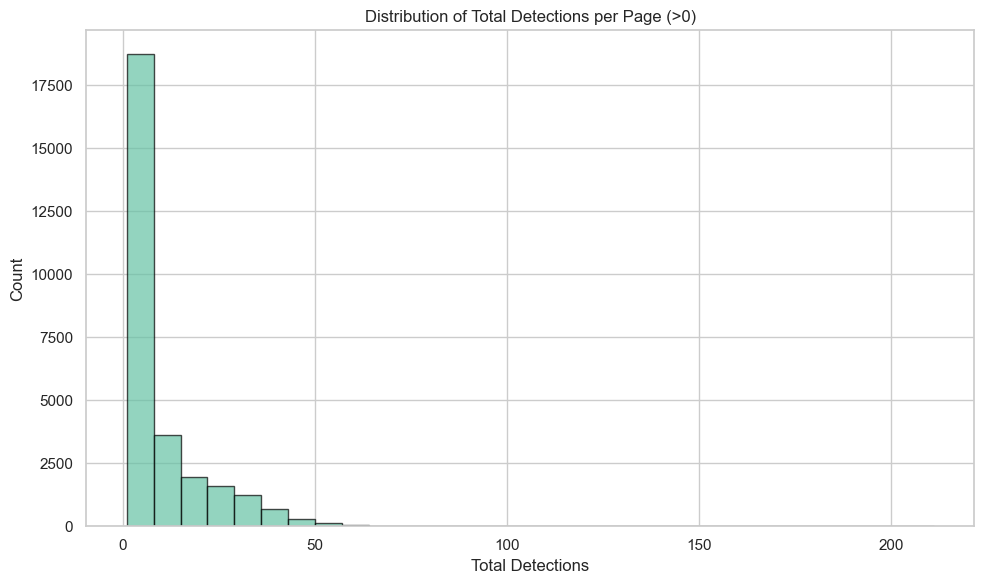

In [3]:
# Cell 4: Distribution of total_detections per page
data = df.loc[df["total_detections"] > 0, "total_detections"]

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
ax.hist(data, **HIST_KWARGS, color=sns.color_palette(PALETTE)[0])
ax.set_title("Distribution of Total Detections per Page (>0)")
ax.set_xlabel("Total Detections")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

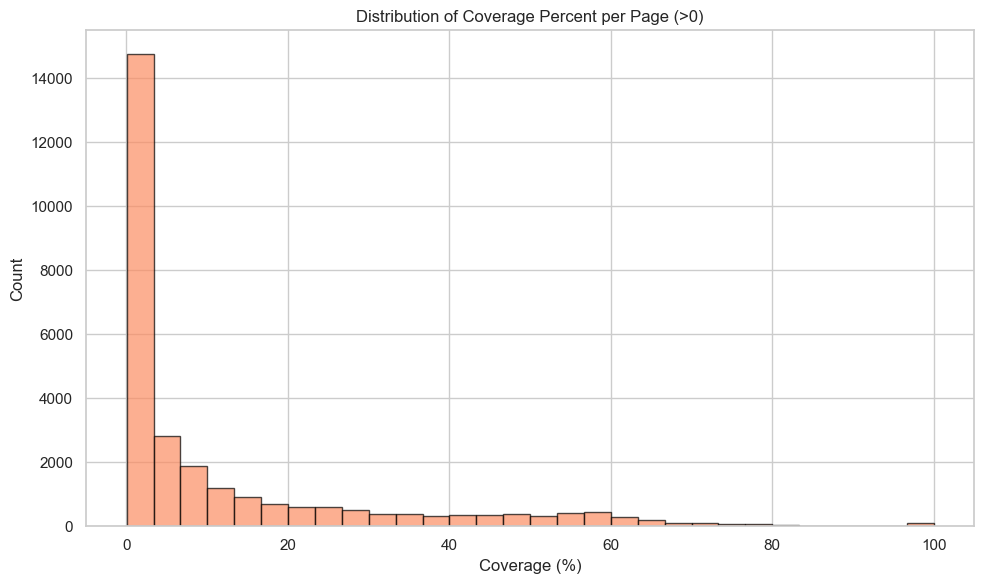

In [4]:
# Cell 5: Distribution of coverage_percent
data = df.loc[df["coverage_percent"] > 0, "coverage_percent"]

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
ax.hist(data, **HIST_KWARGS, color=sns.color_palette(PALETTE)[1])
ax.set_title("Distribution of Coverage Percent per Page (>0)")
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

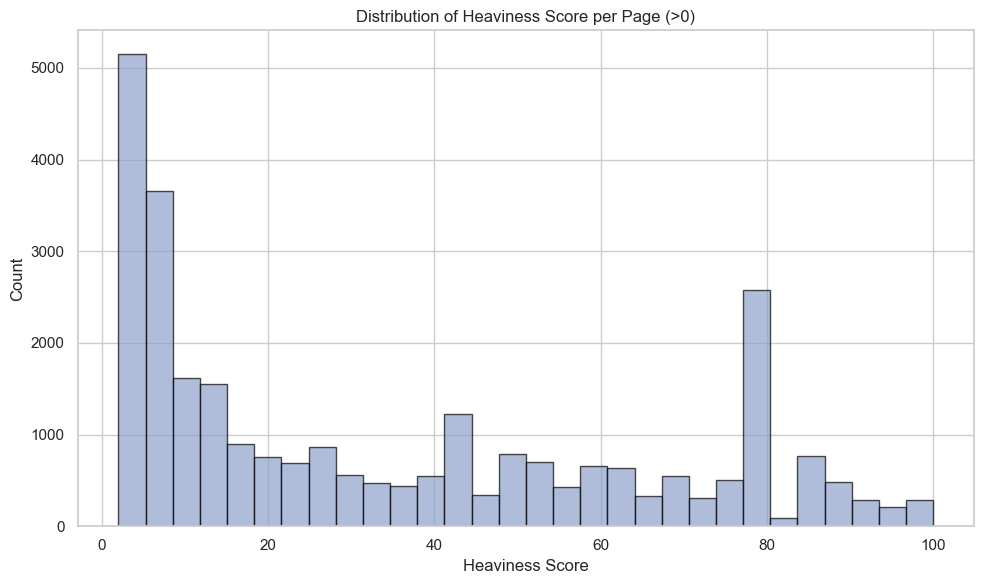

In [5]:
# Cell 6: Distribution of heaviness_score
data = df.loc[df["heaviness_score"] > 0, "heaviness_score"]

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
ax.hist(data, **HIST_KWARGS, color=sns.color_palette(PALETTE)[2])
ax.set_title("Distribution of Heaviness Score per Page (>0)")
ax.set_xlabel("Heaviness Score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Categorical

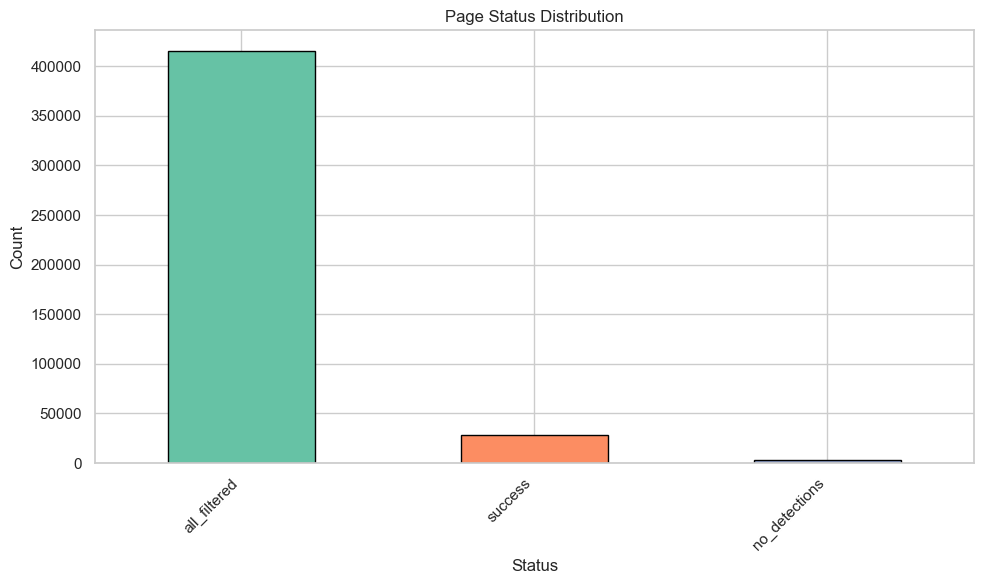

In [6]:
# Cell 7: Count bar chart — status distribution
status_counts = df["status"].value_counts()

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
status_counts.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[:len(status_counts)], edgecolor="black")
ax.set_title("Page Status Distribution")
ax.set_xlabel("Status")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

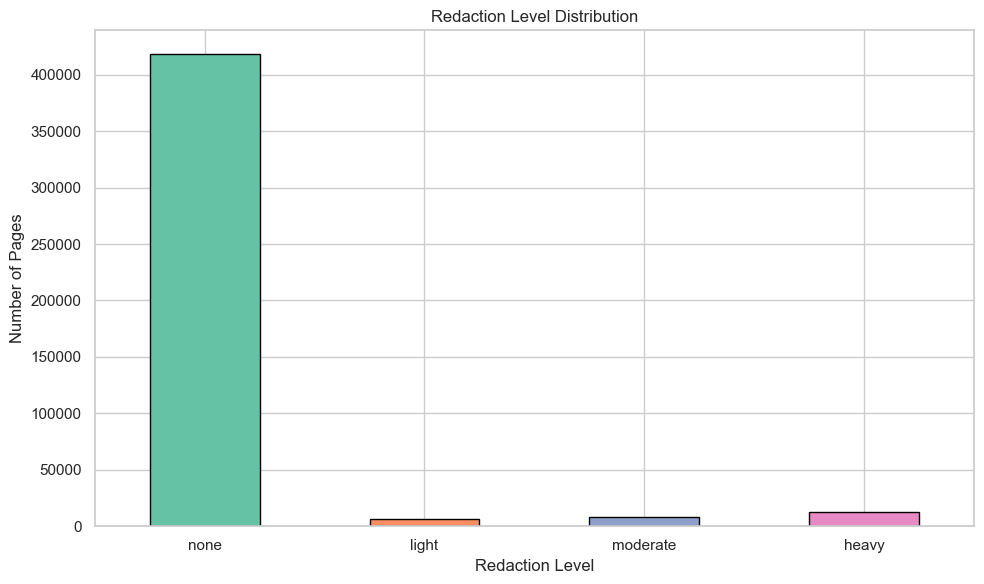

In [7]:
# Cell 8: Count bar chart — redaction_level
level_order = ["none", "light", "moderate", "heavy"]
level_counts = df["redaction_level"].value_counts().reindex(level_order).fillna(0)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
level_counts.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[:len(level_order)], edgecolor="black")
ax.set_title("Redaction Level Distribution")
ax.set_xlabel("Redaction Level")
ax.set_ylabel("Number of Pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

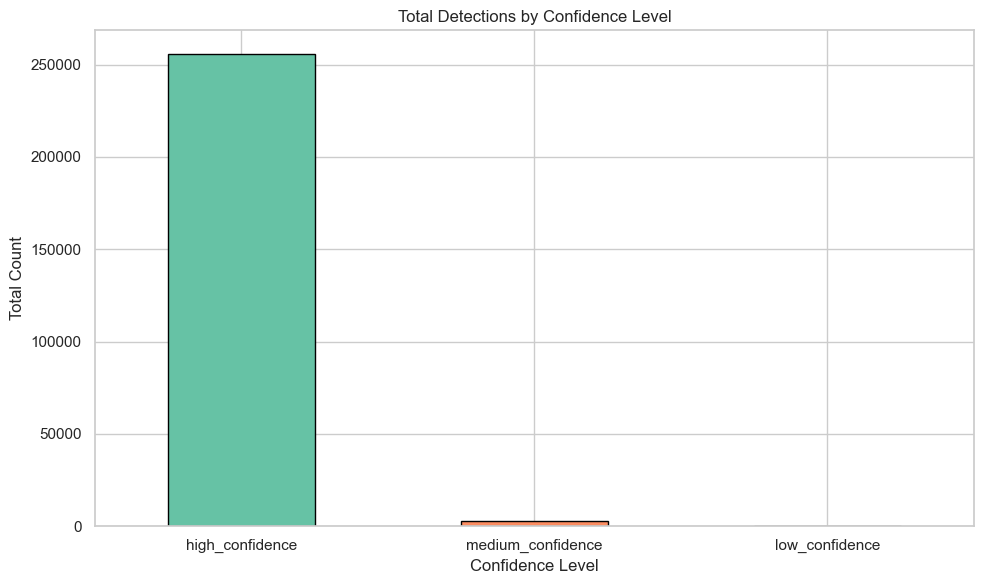

In [8]:
# Cell 9: Stacked bar — confidence breakdown (overall totals)
conf_cols = ["high_confidence", "medium_confidence", "low_confidence"]
conf_totals = df[conf_cols].sum()

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
conf_totals.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[:len(conf_cols)], edgecolor="black")
ax.set_title("Total Detections by Confidence Level")
ax.set_xlabel("Confidence Level")
ax.set_ylabel("Total Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Spatial & Classification

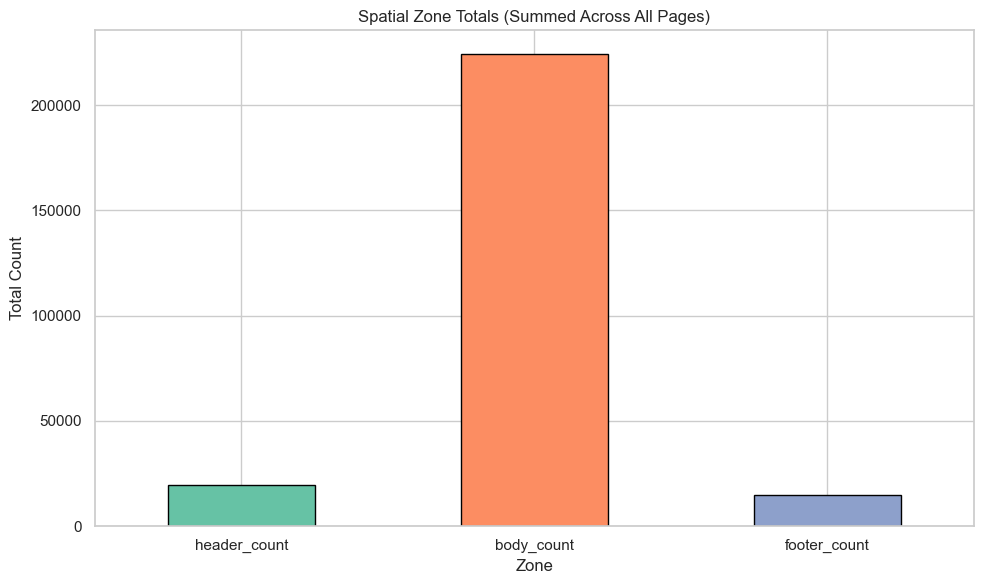

In [9]:
# Cell 10: Bar chart — spatial zone totals
zone_cols = ["header_count", "body_count", "footer_count"]
zone_totals = df[zone_cols].sum()

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
zone_totals.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[:len(zone_cols)], edgecolor="black")
ax.set_title("Spatial Zone Totals (Summed Across All Pages)")
ax.set_xlabel("Zone")
ax.set_ylabel("Total Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

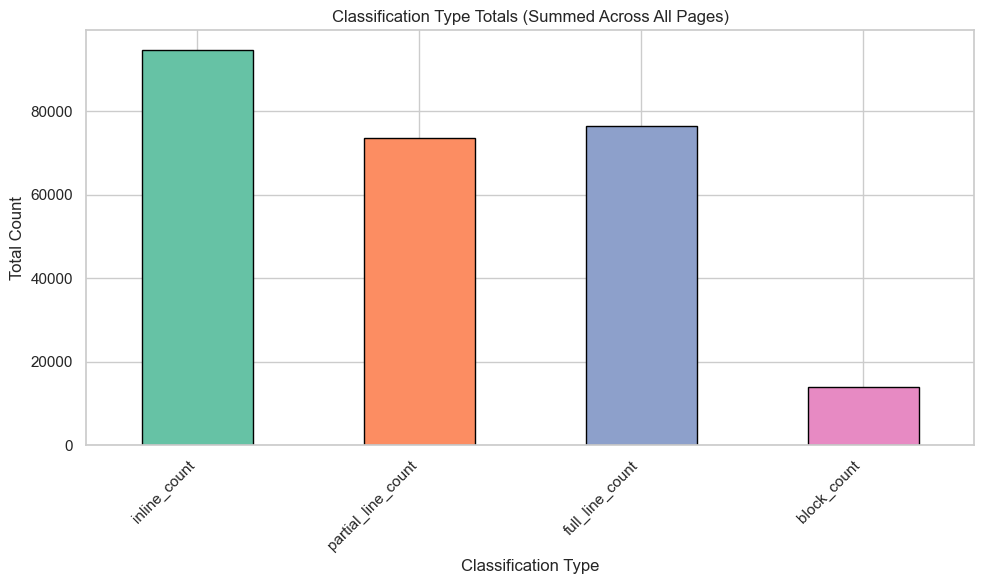

In [10]:
# Cell 11: Bar chart — classification type totals
class_cols = ["inline_count", "partial_line_count", "full_line_count", "block_count"]
class_totals = df[class_cols].sum()

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
class_totals.plot.bar(ax=ax, color=sns.color_palette(PALETTE)[:len(class_cols)], edgecolor="black")
ax.set_title("Classification Type Totals (Summed Across All Pages)")
ax.set_xlabel("Classification Type")
ax.set_ylabel("Total Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Relationships

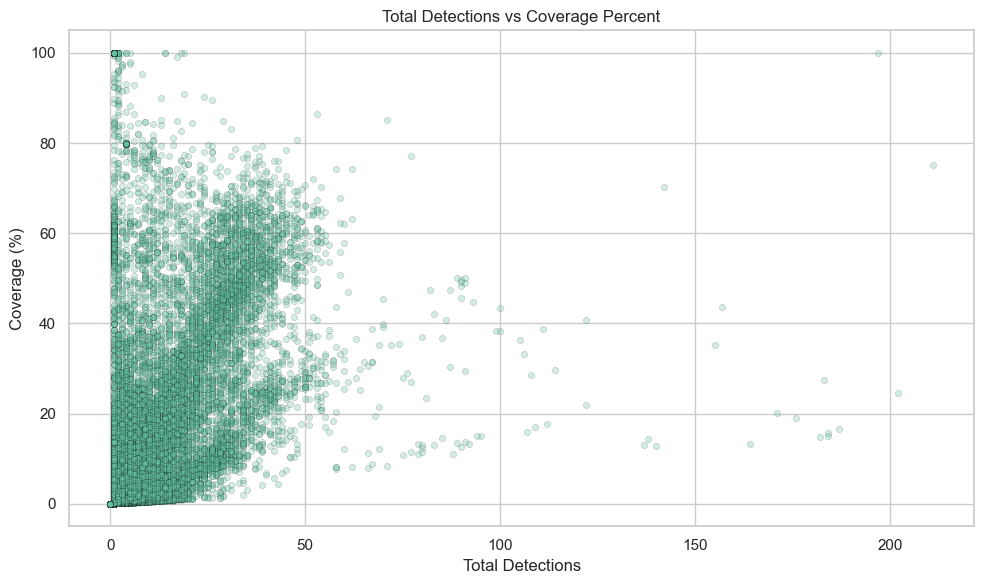

In [11]:
# Cell 12: Scatter — total_detections vs coverage_percent
fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
ax.scatter(df["total_detections"], df["coverage_percent"],
           alpha=0.3, edgecolors="black", linewidths=0.3,
           color=sns.color_palette(PALETTE)[0], s=20)
ax.set_title("Total Detections vs Coverage Percent")
ax.set_xlabel("Total Detections")
ax.set_ylabel("Coverage (%)")
plt.tight_layout()
plt.show()

<positron-console-cell-12>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



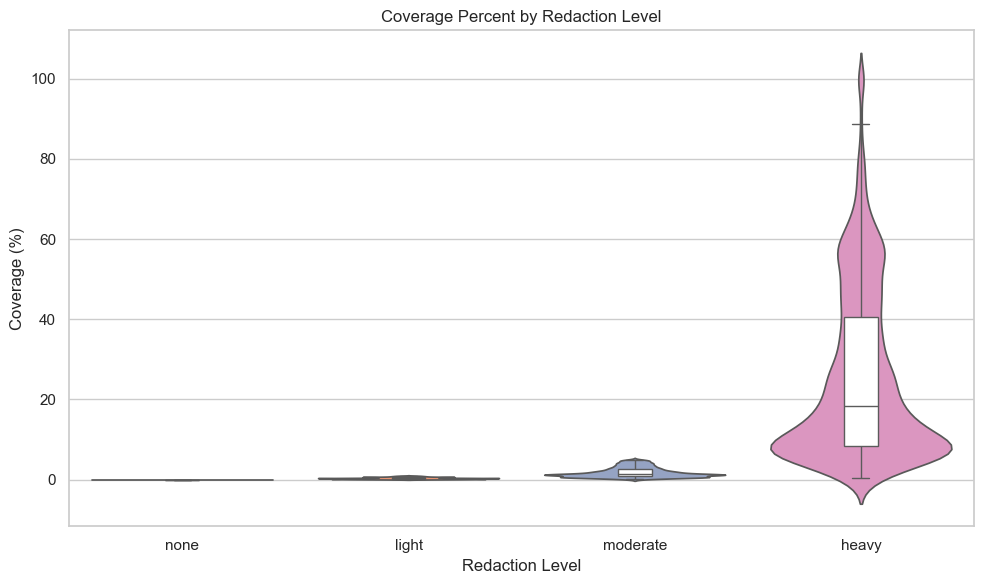

In [12]:
# Cell 13: Violin + box plot — coverage_percent by redaction_level
level_order = ["none", "light", "moderate", "heavy"]
plot_df = df[df["redaction_level"].isin(level_order)].copy()
plot_df["redaction_level"] = pd.Categorical(
    plot_df["redaction_level"], categories=level_order, ordered=True
)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
sns.violinplot(data=plot_df, x="redaction_level", y="coverage_percent",
               palette=PALETTE, inner=None, ax=ax)
sns.boxplot(data=plot_df, x="redaction_level", y="coverage_percent",
            width=0.15, boxprops=dict(facecolor="white", zorder=2),
            ax=ax, fliersize=0)
ax.set_title("Coverage Percent by Redaction Level")
ax.set_xlabel("Redaction Level")
ax.set_ylabel("Coverage (%)")
plt.tight_layout()
plt.show()